<a href="https://colab.research.google.com/github/swathivenkatesan87/yuva-intern/blob/main/Week1_Titanic_Data_Cleaning_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 1 — Data Acquisition, Cleaning and Preprocessing
## Titanic Passenger Dataset

**Student:** Swathi V.  
**Task:** Week 1 — Data Acquisition, Cleaning, and Preprocessing  
**Tools:** Google Colab, Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

### Objective
This notebook documents the acquisition, exploration, cleaning, outlier analysis, and preprocessing of a publicly available Titanic passenger dataset.

**Dataset source:** Kaggle — Titanic: Machine Learning from Disaster  
https://www.kaggle.com/competitions/titanic/data

> Download `train.csv` from Kaggle and upload it when prompted in the next cell.


In [1]:
# STEP 1 — Upload the Kaggle train.csv file
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df_raw = pd.read_csv(file_name)

print("File loaded:", file_name)
print("Dataset shape:", df_raw.shape)
df_raw.head()


Saving train.csv to train.csv
File loaded: train.csv
Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1. Dataset Overview

The dataset contains passenger-level information such as passenger class, name, sex, age, family relationships, ticket, fare, cabin, port of embarkation, and survival status.

For this Week 1 task, the focus is **data quality and preprocessing**, not building a predictive model.


In [2]:
# STEP 2 — Initial inspection
print("Shape:", df_raw.shape)
print("\nColumn names:")
print(df_raw.columns.tolist())

print("\nData types:")
print(df_raw.dtypes)

print("\nFirst 5 rows:")
display(df_raw.head())

print("\nDescriptive statistics:")
display(df_raw.describe(include="all").T)


Shape: (891, 12)

Column names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Dooley, Mr. Patrick",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


,Missing_Count,Missing_Percentage
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


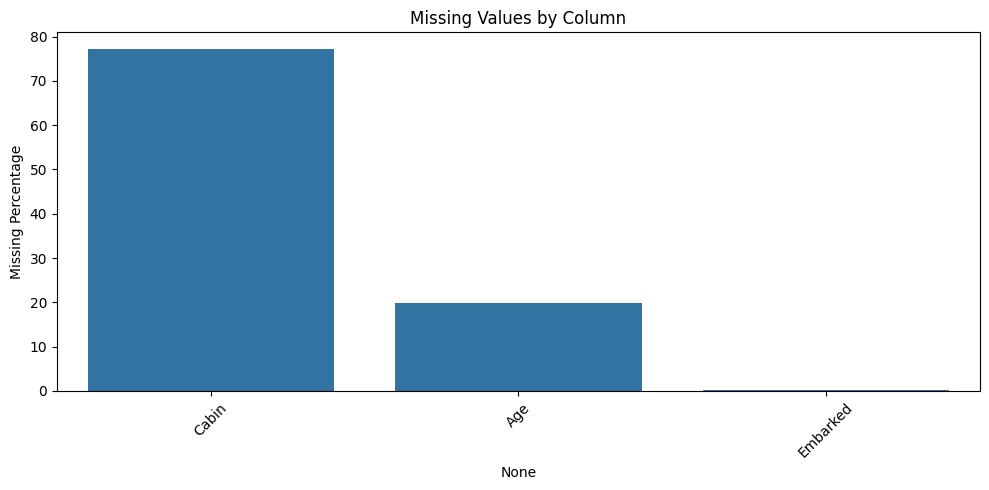

In [3]:
# STEP 3 — Missing values
missing = pd.DataFrame({
    "Missing_Count": df_raw.isna().sum(),
    "Missing_Percentage": (df_raw.isna().mean() * 100).round(2)
}).sort_values("Missing_Count", ascending=False)

display(missing)

plt.figure(figsize=(10,5))
missing_nonzero = missing[missing["Missing_Count"] > 0]
sns.barplot(x=missing_nonzero.index, y=missing_nonzero["Missing_Percentage"])
plt.xticks(rotation=45)
plt.ylabel("Missing Percentage")
plt.title("Missing Values by Column")
plt.tight_layout()
plt.savefig("missing_values_before.png", dpi=200)
plt.show()


In [6]:
# STEP 4 — Duplicate records
duplicate_count = df_raw.duplicated().sum()
print("Duplicate rows:", duplicate_count)

if duplicate_count > 0:
    display(df_raw[df_raw.duplicated(keep=False)].head(20))


Duplicate rows: 0


In [7]:
# STEP 5 — Data consistency and invalid-value checks
print("Unique values in categorical columns:")
for col in ["Sex", "Embarked", "Pclass", "Survived"]:
    print(f"\n{col}:")
    print(df_raw[col].value_counts(dropna=False))

print("\nNumeric range checks:")
for col in ["Age", "SibSp", "Parch", "Fare"]:
    print(f"{col}: min={df_raw[col].min()}, max={df_raw[col].max()}")


Unique values in categorical columns:

Sex:
Sex
male      577
female    314
Name: count, dtype: int64

Embarked:
Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64

Pclass:
Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Survived:
Survived
0    549
1    342
Name: count, dtype: int64

Numeric range checks:
Age: min=0.42, max=80.0
SibSp: min=0, max=8
Parch: min=0, max=6
Fare: min=0.0, max=512.3292


,Column,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
0,Age,20.1250,38.0,17.8750,-6.6875,64.8125,11,1.23
1,SibSp,0.0000,1.0,1.0000,-1.5000,2.5000,46,5.16
2,Parch,0.0000,0.0,0.0000,0.0000,0.0000,213,23.91
3,Fare,7.9104,31.0,23.0896,-26.7240,65.6344,116,13.02


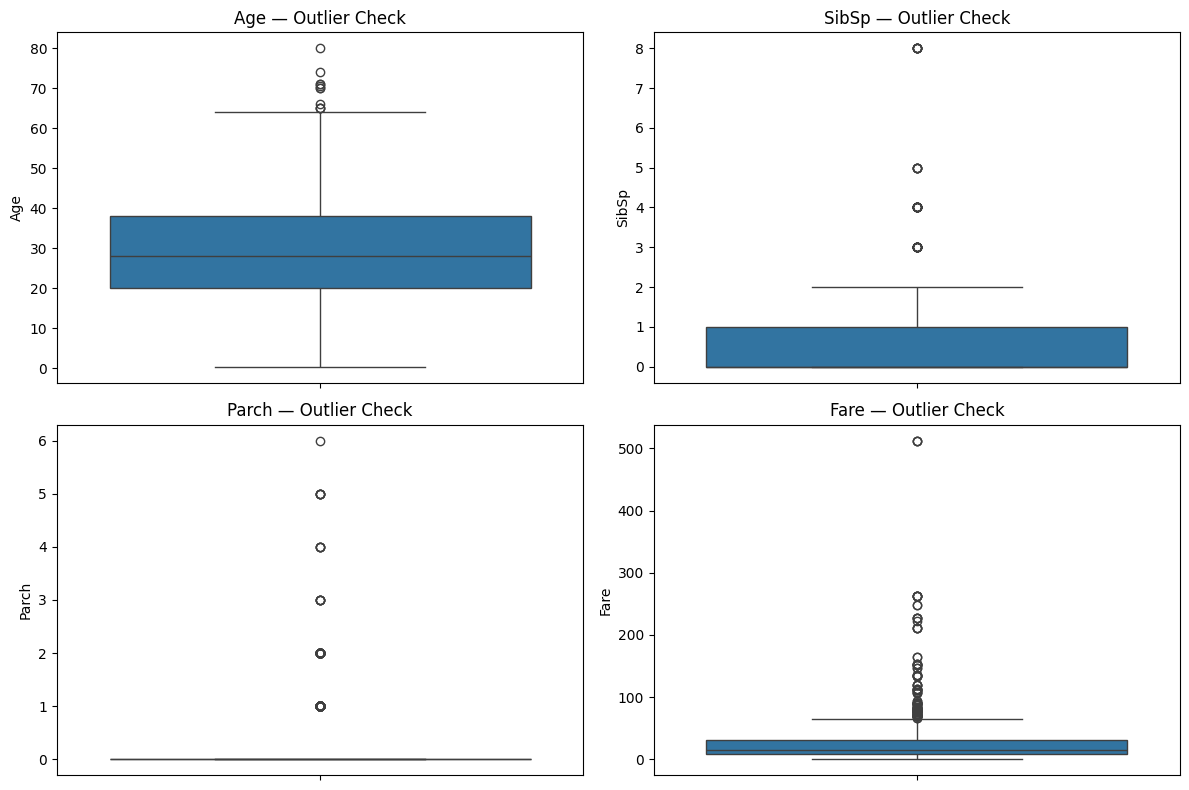

In [8]:
# STEP 6 — Outlier detection using IQR
def iqr_report(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (data[column] < lower) | (data[column] > upper)
    return {
        "Column": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outlier_Count": int(mask.sum()),
        "Outlier_Percentage": round(mask.mean() * 100, 2)
    }

outlier_report = pd.DataFrame([
    iqr_report(df_raw, c) for c in ["Age", "SibSp", "Parch", "Fare"]
])

display(outlier_report)

fig, axes = plt.subplots(2, 2, figsize=(12,8))
for ax, col in zip(axes.ravel(), ["Age", "SibSp", "Parch", "Fare"]):
    sns.boxplot(y=df_raw[col], ax=ax)
    ax.set_title(f"{col} — Outlier Check")
plt.tight_layout()
plt.savefig("outliers_before.png", dpi=200)
plt.show()


## 2. Cleaning Strategy

The following decisions are used:

1. **Age:** Missing values are imputed using the median because age is numerical and the median is less sensitive to extreme values.
2. **Embarked:** A small number of missing categorical values are filled using the mode.
3. **Cabin:** The raw `Cabin` field has substantial missingness. Instead of simply deleting all rows, a useful derived feature `CabinKnown` is created to indicate whether cabin information exists. The original high-missingness field is then removed from the modeling-ready dataset.
4. **Duplicates:** Exact duplicate rows are removed if present.
5. **Impossible numerical values:** Negative ages or negative fares, if present, are treated as invalid and converted to missing before imputation.
6. **Outliers:** IQR outliers are investigated but are **not automatically deleted**. Extreme fares can represent legitimate passengers/ticket groups, so blindly removing them could discard valid information.
7. **Categorical standardization:** Text categories are stripped of unnecessary whitespace and standardized.
8. **Feature engineering:** `FamilySize` and `IsAlone` are created from `SibSp` and `Parch`.


In [9]:
# STEP 7 — Create a working copy
df = df_raw.copy()

# Remove exact duplicates
before_duplicates = len(df)
df = df.drop_duplicates().copy()
duplicates_removed = before_duplicates - len(df)

# Treat impossible numeric values as missing
df.loc[df["Age"] < 0, "Age"] = np.nan
df.loc[df["Fare"] < 0, "Fare"] = np.nan

# Standardize text columns
df["Sex"] = df["Sex"].astype(str).str.strip().str.lower()
df["Embarked"] = df["Embarked"].astype("string").str.strip().str.upper()

# Missing-value treatment
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Cabin information as a useful indicator
df["CabinKnown"] = df["Cabin"].notna().astype(int)

# Remove raw high-missingness Cabin column
df = df.drop(columns=["Cabin"])

# Feature engineering
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

print("Duplicates removed:", duplicates_removed)
display(df.head())


Duplicates removed: 0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,CabinKnown,FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1,2,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1,2,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0,1,1


In [10]:
# STEP 8 — Verify cleaning
clean_missing = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": (df.isna().mean() * 100).round(2)
}).sort_values("Missing_Count", ascending=False)

display(clean_missing)

print("Cleaned shape:", df.shape)
print("Remaining duplicate rows:", df.duplicated().sum())


,Missing_Count,Missing_Percentage
PassengerId,0,0.0
Survived,0,0.0
Pclass,0,0.0
Name,0,0.0
Sex,0,0.0
Age,0,0.0
SibSp,0,0.0
Parch,0,0.0
Ticket,0,0.0
Fare,0,0.0


Cleaned shape: (891, 14)
Remaining duplicate rows: 0


,Metric,Before,After
0,Rows,891,891
1,Columns,12,14
2,Total missing cells,866,0
3,Duplicate rows,0,0


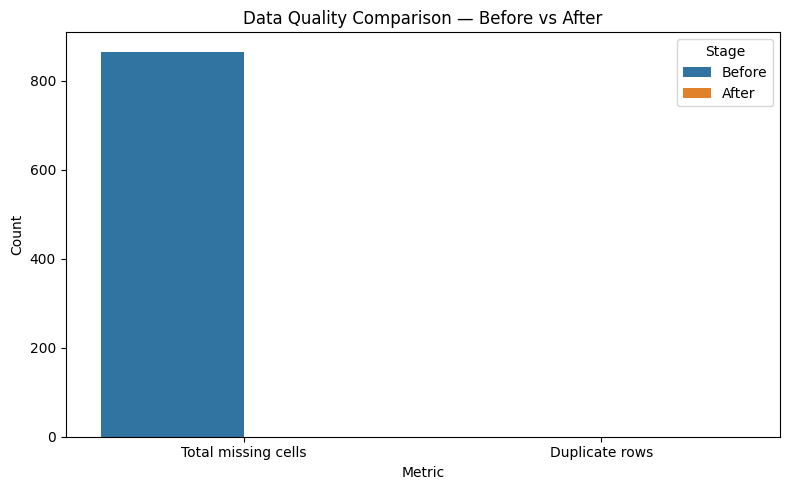

In [11]:
# STEP 9 — Before vs after data-quality summary
before_missing = int(df_raw.isna().sum().sum())
after_missing = int(df.isna().sum().sum())

summary = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Total missing cells",
        "Duplicate rows"
    ],
    "Before": [
        df_raw.shape[0],
        df_raw.shape[1],
        before_missing,
        int(df_raw.duplicated().sum())
    ],
    "After": [
        df.shape[0],
        df.shape[1],
        after_missing,
        int(df.duplicated().sum())
    ]
})

display(summary)

plt.figure(figsize=(8,5))
plot_df = summary[summary["Metric"].isin(["Total missing cells", "Duplicate rows"])]
plot_long = plot_df.melt(id_vars="Metric", var_name="Stage", value_name="Count")
sns.barplot(data=plot_long, x="Metric", y="Count", hue="Stage")
plt.title("Data Quality Comparison — Before vs After")
plt.tight_layout()
plt.savefig("before_after_quality.png", dpi=200)
plt.show()


## 3. Encoding and Scaling

For a modeling-ready dataset, categorical variables need numerical representation.

- `Sex` is converted into a binary variable.
- `Embarked` and `Pclass` are one-hot encoded.
- Numerical features are standardized using `StandardScaler`.

The original cleaned dataframe is retained separately so the report can distinguish **cleaning** from **model-oriented preprocessing**.


In [12]:
# STEP 10 — Prepare a modeling-ready dataset
from sklearn.preprocessing import StandardScaler

model_df = df.copy()

# Drop identifier/text fields that are not directly used in the processed feature matrix
model_df = model_df.drop(columns=["Name", "Ticket", "PassengerId"], errors="ignore")

# One-hot encoding
model_df = pd.get_dummies(
    model_df,
    columns=["Sex", "Embarked", "Pclass"],
    drop_first=False,
    dtype=int
)

numeric_cols = [
    c for c in ["Age", "SibSp", "Parch", "Fare", "FamilySize"]
    if c in model_df.columns
]

scaler = StandardScaler()
model_df[numeric_cols] = scaler.fit_transform(model_df[numeric_cols])

print("Model-ready shape:", model_df.shape)
display(model_df.head())


Model-ready shape: (891, 16)


,Survived,Age,SibSp,Parch,Fare,CabinKnown,FamilySize,IsAlone,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Pclass_1,Pclass_2,Pclass_3
0,0,-0.565736,0.432793,-0.473674,-0.502445,0,0.059160,0,0,1,0,0,1,0,0,1
1,1,0.663861,0.432793,-0.473674,0.786845,1,0.059160,0,1,0,1,0,0,1,0,0
2,1,-0.258337,-0.474545,-0.473674,-0.488854,0,-0.560975,1,1,0,0,0,1,0,0,1
3,1,0.433312,0.432793,-0.473674,0.420730,1,0.059160,0,1,0,0,0,1,1,0,0
4,0,0.433312,-0.474545,-0.473674,-0.486337,0,-0.560975,1,0,1,0,0,1,0,0,1


In [13]:
# STEP 11 — Save outputs
os.makedirs("outputs", exist_ok=True)
os.makedirs("figures", exist_ok=True)

df.to_csv("outputs/titanic_cleaned.csv", index=False)
model_df.to_csv("outputs/titanic_preprocessed.csv", index=False)

# Move/copy figures into a single folder
import shutil
for f in ["missing_values_before.png", "outliers_before.png", "before_after_quality.png"]:
    if os.path.exists(f):
        shutil.copy(f, os.path.join("figures", f))

print("Saved:")
print("- outputs/titanic_cleaned.csv")
print("- outputs/titanic_preprocessed.csv")
print("- figures/*.png")


Saved:
- outputs/titanic_cleaned.csv
- outputs/titanic_preprocessed.csv
- figures/*.png


In [14]:
# STEP 12 — Final quality report for the Word document
final_report = pd.DataFrame({
    "Metric": [
        "Original rows",
        "Original columns",
        "Final cleaned rows",
        "Final cleaned columns",
        "Duplicates removed",
        "Missing cells before",
        "Missing cells after",
        "New features created"
    ],
    "Value": [
        df_raw.shape[0],
        df_raw.shape[1],
        df.shape[0],
        df.shape[1],
        duplicates_removed,
        before_missing,
        after_missing,
        "CabinKnown, FamilySize, IsAlone"
    ]
})

display(final_report)
final_report.to_csv("outputs/final_quality_summary.csv", index=False)


,Metric,Value
0,Original rows,891
1,Original columns,12
2,Final cleaned rows,891
3,Final cleaned columns,14
4,Duplicates removed,0
5,Missing cells before,866
6,Missing cells after,0
7,New features created,"CabinKnown, FamilySize, IsAlone"


# Conclusion

The dataset was systematically inspected, cleaned, and transformed for subsequent analysis. Missing values, duplicates, invalid numerical values, categorical inconsistencies, and potential outliers were investigated. The preprocessing strategy intentionally avoided blindly deleting unusual observations, because an extreme observation can represent a valid real-world case.

The resulting cleaned dataset is suitable for further exploratory analysis, visualization, or machine-learning experiments. The preprocessing decisions and their possible effects on downstream analysis are documented in the Week 1 report.


## References

1. Kaggle. *Titanic — Machine Learning from Disaster*. Dataset and data dictionary:
https://www.kaggle.com/competitions/titanic/data

2. Kaggle. *Titanic — Machine Learning from Disaster: Evaluation and dataset description*:
https://www.kaggle.com/competitions/titanic/overview/evaluation
